In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [4]:
# Load spam dataset directly from URL - no download needed!
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# How many spam vs ham?
print(df['label'].value_counts())

# Percentage
print("\nSpam percentage:", round(df['label'].value_counts()['spam'] / len(df) * 100, 2), "%")
print("Ham percentage:", round(df['label'].value_counts()['ham'] / len(df) * 100, 2), "%")

label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage: 13.41 %
Ham percentage: 86.59 %


In [6]:
# Convert label to numbers
# ham = 0, spam = 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Define X (input) and y (output)
X = df['message']  # the email text
y = df['label_num']  # 0 or 1

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [7]:
# Step 1: Convert text to numbers using CountVectorizer
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Step 2: Train Naive Bayes model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
# Make predictions
y_pred = model.predict(X_test_vec)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Accuracy: 99.19 %

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       966
        Spam       1.00      0.94      0.97       149

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



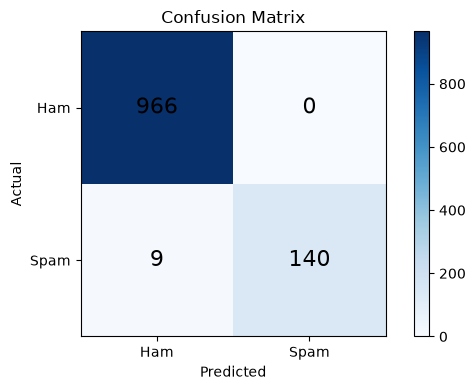

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.yticks([0, 1], ['Ham', 'Spam'])

# Add numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', 
                 fontsize=16, color='black')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [10]:
# Test with custom messages
def predict_spam(message):
    msg_vec = vectorizer.transform([message])
    prediction = model.predict(msg_vec)[0]
    probability = model.predict_proba(msg_vec)[0]
    
    if prediction == 1:
        print(f"Message: '{message}'")
        print(f"Result: SPAM 🚨 (confidence: {round(probability[1]*100, 2)}%)\n")
    else:
        print(f"Message: '{message}'")
        print(f"Result: HAM ✅ (confidence: {round(probability[0]*100, 2)}%)\n")

# Test it!
predict_spam("Win a free iPhone now! Click here!!!")
predict_spam("Hey, are you coming for dinner tonight?")
predict_spam("Congratulations! You won $1000 cash prize!")
predict_spam("Can you send me the notes for tomorrow's class?")

Message: 'Win a free iPhone now! Click here!!!'
Result: SPAM 🚨 (confidence: 97.68%)

Message: 'Hey, are you coming for dinner tonight?'
Result: HAM ✅ (confidence: 100.0%)

Message: 'Congratulations! You won $1000 cash prize!'
Result: SPAM 🚨 (confidence: 100.0%)

Message: 'Can you send me the notes for tomorrow's class?'
Result: HAM ✅ (confidence: 99.99%)

